Для Котиев Муслим Магометович
xa = 0.0206 mol.%, xy = 0.9699 mol.%, rho_c = 0.6799 кг/м³
При P = 50.0 атм, T = 310.0 K:
  Z = 0.926484
  Bg = 0.019595


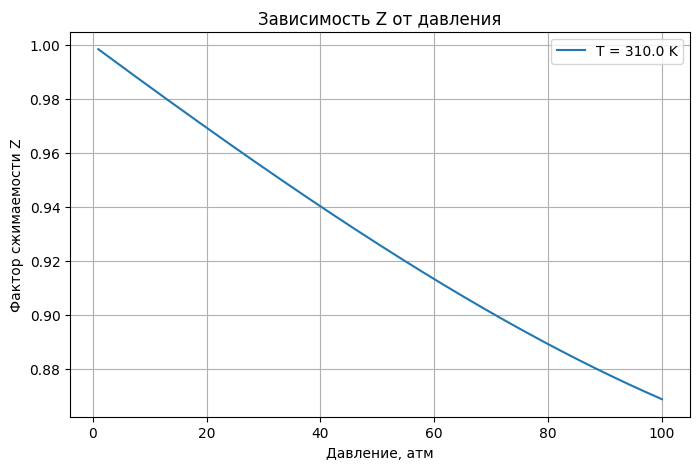

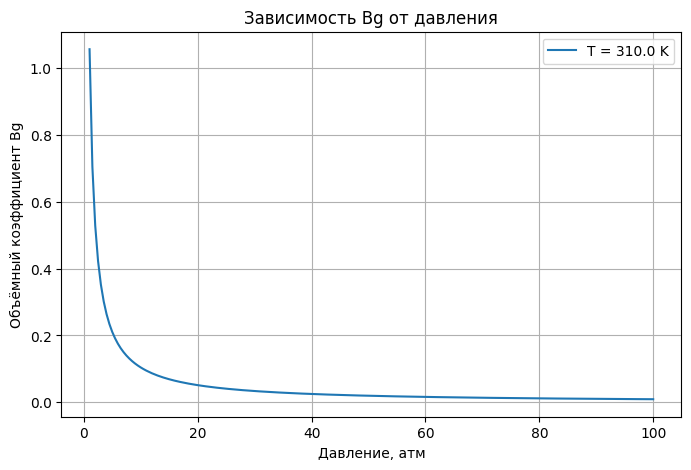

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

class Fluid:
    """
    Класс для расчёта свойств природного газа по методике GERG-91 мод.
    (ГОСТ 30319.2-96, раздел 3.2.3)
    """
    Pstd = 1.0          # стандартное давление, атм
    Tstd = 293.15       # стандартная температура, K

    def __init__(self, rho_c: float, xa: float, xy: float):
        """
        Параметры
        ----------
        rho_c : float
            Плотность газа в стандартных условиях, кг/м³.
        xa : float
            Мольная доля азота (N₂) (в долях, не в процентах).
        xy : float
            Мольная доля диоксида углерода (CO₂) (в долях).
        """
        self.rho_c = rho_c
        self.xa = xa
        self.xy = xy
        # Мольная доля эквивалентного углеводорода
        self.x_eq = 1.0 - xa - xy

        # Фактор сжимаемости при стандартных условиях (формула 36)
        self.z_c = 1.0 - (0.0741 * rho_c - 0.006 - 0.063 * xa - 0.0575 * xy) ** 2

        # Молярная масса эквивалентного углеводорода (формула 35)
        self.M3 = (24.05525 * self.z_c * rho_c - 28.0135 * xa - 44.01 * xy) / self.x_eq

        # Параметр H (формула 34)
        self.H = 128.64 + 47.479 * self.M3

    def _B1(self, T: float) -> float:
        """Коэффициент B1 (формула 23)"""
        return (-0.425468 +
                2.865e-3 * T -
                4.62073e-6 * T**2 +
                (8.77118e-4 - 5.56281e-6 * T + 8.81514e-9 * T**2) * self.H +
                (-8.24747e-7 + 4.31436e-9 * T - 6.08319e-12 * T**2) * self.H**2)

    def _B2(self, T: float) -> float:
        """Коэффициент B2 (формула 24)"""
        return -0.1446 + 0.74091e-3 * T - 0.91195e-6 * T**2

    def _B23(self, T: float) -> float:
        """Коэффициент B23 (формула 25)"""
        return -0.339693 + 0.161176e-2 * T - 0.204429e-5 * T**2

    def _B3(self, T: float) -> float:
        """Коэффициент B3 (формула 26)"""
        return -0.86834 + 0.40376e-2 * T - 0.51657e-5 * T**2

    def _C1(self, T: float) -> float:
        """Коэффициент C1 (формула 27)"""
        return (-0.302488 +
                1.95861e-3 * T -
                3.16302e-6 * T**2 +
                (6.46422e-4 - 4.22876e-6 * T + 6.88157e-9 * T**2) * self.H +
                (-3.32805e-7 + 2.2316e-9 * T - 3.67713e-12 * T**2) * self.H**2)

    def _C2(self, T: float) -> float:
        """Коэффициент C2 (формула 28)"""
        return 7.8498e-3 - 3.9895e-5 * T + 6.1187e-8 * T**2

    def _C3(self, T: float) -> float:
        """Коэффициент C3 (формула 29)"""
        return 2.0513e-3 + 3.4888e-5 * T - 8.3703e-8 * T**2

    def _C223(self, T: float) -> float:
        """Коэффициент C223 (формула 30)"""
        return 5.52066e-3 - 1.68609e-5 * T + 1.57169e-8 * T**2

    def _C233(self, T: float) -> float:
        """Коэффициент C233 (формула 31)"""
        return 3.58783e-3 + 8.06674e-6 * T - 3.25798e-8 * T**2

    def _B_star(self, T: float) -> float:
        """Параметр B* (формула 32)"""
        return 0.72 + 1.875e-5 * (320.0 - T) ** 2

    def _C_star(self, T: float) -> float:
        """Параметр C* (формула 33)"""
        return 0.92 + 0.0013 * (T - 270.0)

    def get_Z(self, P: float, T: float) -> float:
        """
        Рассчитать фактор сжимаемости z (compressibility factor)
        по методике GERG-91 мод.

        Параметры
        ----------
        P : float
            Давление, атм.
        T : float
            Температура, К.

        Возвращает
        ----------
        float
            Фактор сжимаемости z.
        """
        # Перевод давления в МПа (1 атм = 0.101325 МПа)
        P_MPa = P * 0.101325

        # Коэффициенты, зависящие от температуры
        B1 = self._B1(T)
        B2 = self._B2(T)
        B23 = self._B23(T)
        B3 = self._B3(T)
        C1 = self._C1(T)
        C2 = self._C2(T)
        C223 = self._C223(T)
        C233 = self._C233(T)
        C3 = self._C3(T)
        B_star = self._B_star(T)
        C_star = self._C_star(T)

        # Константы бинарного взаимодействия
        Z13 = -0.865      # используется как 2*Z13 = -1.73
        Y12 = 0.92
        Y13 = 0.92
        Y123 = 1.1

        # Мольные доли
        x_eq = self.x_eq
        x_N2 = self.xa
        x_CO2 = self.xy

        # Расчёт Bm (формула 20)
        term1 = x_eq**2 * B1
        term2 = x_eq * x_N2 * B_star * (B1 + B2)
        term3 = -1.73 * x_eq * x_CO2 * np.sqrt(B1 * B3)
        term4 = x_N2**2 * B2
        term5 = 2.0 * x_eq * x_CO2 * B23
        term6 = x_CO2**2 * B3
        Bm = term1 + term2 + term3 + term4 + term5 + term6
        
        # Расчёт Cm (формула 21)
        # Предварительные произведения
        C1_2 = C1**2
        C2_2 = C2**2
        C3_2 = C3**2
        CA112 = C1_2 * C2          # C1^2 * C2
        CA113 = C1_2 * C3          # C1^2 * C3
        CA122 = C1 * C2_2          # C1 * C2^2
        CA123 = C1 * C2 * C3       # C1 * C2 * C3
        CA133 = C1 * C3_2          # C1 * C3^2

        # Члены с кубическими корнями
        cbrt112 = np.cbrt(CA112)
        cbrt113 = np.cbrt(CA113)
        cbrt122 = np.cbrt(CA122)
        cbrt123 = np.cbrt(CA123)
        cbrt133 = np.cbrt(CA133)

        Cm = (x_eq**3 * C1 +
              3.0 * x_eq**2 * x_N2 * cbrt112 * C_star +
              3.0 * x_eq**2 * x_CO2 * cbrt113 * Y13 +
              3.0 * x_eq * x_N2**2 * cbrt122 * C_star +
              6.0 * x_eq * x_N2 * x_CO2 * cbrt123 * Y123 +
              3.0 * x_eq * x_CO2**2 * cbrt133 * Y13 +
              x_N2**3 * C2 +
              3.0 * x_N2**2 * x_CO2 * C223 +
              3.0 * x_N2 * x_CO2**2 * C233 +
              x_CO2**3 * C3)

        # Параметр b (формула 43)
        b = 1000.0 * P_MPa / (2.7715 * T)

        B0 = b * Bm
        C0 = b**2 * Cm

        A1 = 1.0 + B0
        A0 = 1.0 + 1.5 * (B0 + C0)

        # Решение кубического уравнения (формулы 37-40)
        D = A0**2 - A1**3
        if D < 0:
            # В рабочем диапазоне параметров этого не должно происходить
            return np.nan

        sqrtD = np.sqrt(D)
        # Вычисляем A2 = (A0 - sqrtD)^(1/3)
        A2 = np.cbrt(A0 - sqrtD)
        z = (1.0 + A2 + A1 / A2) / 3.0
        return z

    def get_Bg(self, P: float, T: float) -> float:
        """
        Рассчитать объёмный коэффициент расширения газа Bg.

        Bg = (Pstd * Z * T) / (P * Tstd)

        Параметры
        ----------
        P : float
            Давление, атм.
        T : float
            Температура, К.

        Возвращает
        ----------
        float
            Объёмный коэффициент расширения Bg.
        """
        z = self.get_Z(P, T)
        return (self.Pstd * z * T) / (P * self.Tstd)

    def plot_Z(self, T_fixed: float = 310.0):
        """
        Построить график Z(P) при фиксированной температуре.
        Диапазон давлений: [1, 100] атм.
        """
        P_range = np.linspace(1, 100, 200)
        Z_vals = [self.get_Z(P, T_fixed) for P in P_range]

        plt.figure(figsize=(8, 5))
        plt.plot(P_range, Z_vals, label=f'T = {T_fixed} K')
        plt.xlabel('Давление, атм')
        plt.ylabel('Фактор сжимаемости Z')
        plt.title('Зависимость Z от давления')
        plt.grid(True)
        plt.legend()
        plt.show()

    def plot_Bg(self, T_fixed: float = 310.0):
        """
        Построить график Bg(P) при фиксированной температуре.
        Диапазон давлений: [1, 100] атм.
        """
        P_range = np.linspace(1, 100, 200)
        Bg_vals = [self.get_Bg(P, T_fixed) for P in P_range]

        plt.figure(figsize=(8, 5))
        plt.plot(P_range, Bg_vals, label=f'T = {T_fixed} K')
        plt.xlabel('Давление, атм')
        plt.ylabel('Объёмный коэффициент Bg')
        plt.title('Зависимость Bg от давления')
        plt.grid(True)
        plt.legend()
        plt.show()


if __name__ == "__main__":
    # Загрузка данных
    df = pd.read_csv('../hw2_data.csv', sep=';', index_col=0)
    # Поиск строки с фамилией Котиев
    target = "Котиев Муслим Магометович"
    row = df[df['student'] == target].iloc[0]
    xa_percent = row['xa, mol. %']
    xy_percent = row['xy, mol. %']
    rho_c = row['rho_c, kg/m3']

    # Перевод процентов в доли
    xa = xa_percent / 100.0
    xy = xy_percent / 100.0

    # Создание объекта
    fluid = Fluid(rho_c, xa, xy)

    # Тестовый расчёт при P = 50 атм, T = 310 К
    P_test = 50.0
    T_test = 310.0
    z_val = fluid.get_Z(P_test, T_test)
    bg_val = fluid.get_Bg(P_test, T_test)
    print(f"Для {target}")
    print(f"xa = {xa_percent:.4f} mol.%, xy = {xy_percent:.4f} mol.%, rho_c = {rho_c} кг/м³")
    print(f"При P = {P_test} атм, T = {T_test} K:")
    print(f"  Z = {z_val:.6f}")
    print(f"  Bg = {bg_val:.6f}")

    # Построение графиков
    fluid.plot_Z(T_fixed=310.0)
    fluid.plot_Bg(T_fixed=310.0)

,"pressure, atm","viscosity, cP",Z,Bg
0,1.000000,0.018312,0.998442,1.055832
1,3.010101,0.018321,0.995319,0.349666
2,5.020202,0.018330,0.992207,0.209003
3,7.030303,0.018339,0.989105,0.148778
4,9.040404,0.018349,0.986015,0.115337
5,11.050505,0.018359,0.982936,0.094062
6,13.060606,0.018369,0.979871,0.079337
7,15.070707,0.018379,0.976818,0.068541
8,17.080808,0.018389,0.973779,0.060287
9,19.090909,0.018400,0.970754,0.053772


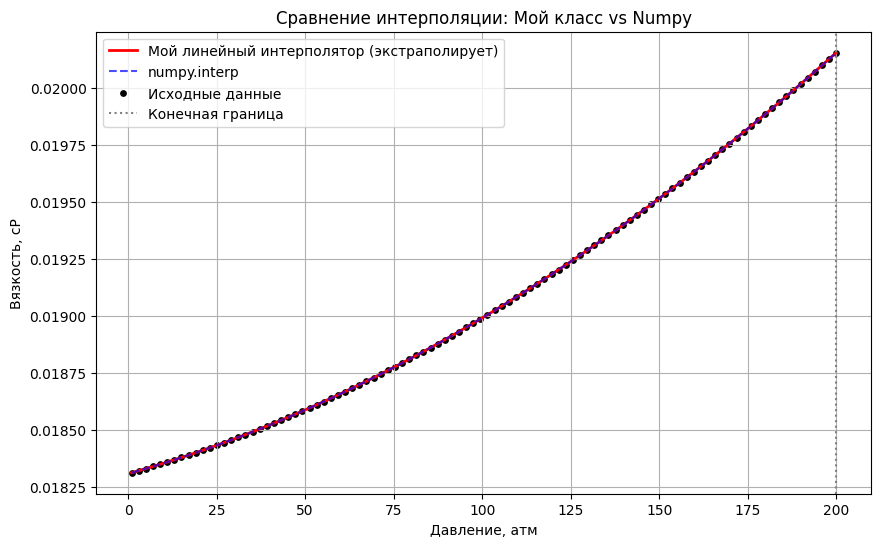

In [10]:
class LinearInterpolator:
    def __init__(self, x, y):
        if len(x) != len(y):
            raise ValueError("Массивы x и y должны быть одной длины")
        self.x = list(x)
        self.y = list(y)

    def predict(self, xp):
        # Обработка правой границы (включая случай xp == x_last)
        # через экстраполяцию по двум последним точкам
        if xp >= self.x[-1]:
            x_pre = self.x[-2]
            x_last = self.x[-1]
            y_pre = self.y[-2]
            y_last = self.y[-1]
            # Формула экстраполяции
            return y_last + (y_last - y_pre) / (x_last - x_pre) * (xp - x_last)
        
        # Левая граница (экстраполяция по первым двум точкам)
        if xp < self.x[0]:
            x_first = self.x[0]
            x_next = self.x[1]
            y_first = self.y[0]
            y_next = self.y[1]
            return y_first + (y_next - y_first) / (x_next - x_first) * (xp - x_first)

        # Основная интерполяция
        for i in range(len(self.x) - 1):
            if self.x[i] <= xp < self.x[i+1]:
                x_i, x_i1 = self.x[i], self.x[i+1]
                y_i, y_i1 = self.y[i], self.y[i+1]
                return y_i + (y_i1 - y_i) / (x_i1 - x_i) * (xp - x_i)

# 3. Выполнение задания
df = pd.read_csv('../interp_data.csv', sep=';')
T_fixed = 310.0
# Мои данные
fluid = Fluid(rho_c=0.6799, xa=0.000206, xy=0.009699)

df['Z'] = df['pressure, atm'].apply(lambda p: fluid.get_Z(p, T_fixed))
df['Bg'] = df['pressure, atm'].apply(lambda p: fluid.get_Bg(p, T_fixed))

# Проверим, что столбцы добавились
display(df.head(10))

# 4. Сравнение
p_range = np.arange(1, 201, 1) # от 1 до 200 с шагом 1
my_interp = LinearInterpolator(df['pressure, atm'], df['viscosity, cP'])

y_my = [my_interp.predict(p) for p in p_range]
y_np = np.interp(p_range, df['pressure, atm'], df['viscosity, cP'])

# 5. Визуализация
plt.figure(figsize=(10, 6))
plt.plot(p_range, y_my, 'r-', label='Мой линейный интерполятор (экстраполирует)', linewidth=2)
plt.plot(p_range, y_np, 'b--', label='numpy.interp', alpha=0.7)
plt.scatter(df['pressure, atm'], df['viscosity, cP'], color='black', s=15, label='Исходные данные')
plt.axvline(df['pressure, atm'].max(), color='gray', linestyle=':', label='Конечная граница')
plt.title('Сравнение интерполяции: Мой класс vs Numpy')
plt.xlabel('Давление, атм')
plt.ylabel('Вязкость, cP')
plt.legend()
plt.grid(True)
plt.show()